# Setup

In [93]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from google.colab import drive

cache_path = "/content/huggingface_cache"
os.makedirs(cache_path, exist_ok=True)
os.environ['HF_HOME'] = cache_path

In [4]:
df = pd.read_csv("narratives.csv", index_col=0)
df

,Assessments_Primary_Problem,Report_1_Narrative,Report_2_Narrative
2260174,ambiguous,Aircraft vectored in within 1NM to final appro...,NaN
2260249,ambiguous,While on short final we received a glideslope ...,NaN
2260370,aircraft,Flying at cruise; FL350; the FO was the PF and...,At cruise; FL350; during level-off; the Captai...
2261277,humanfactors,On Day 0 around XA:30; I forgot to get LAANC a...,NaN
2261317,procedure,Divert into ZZZ from ZZZ1. FO flying. Vectors ...,Extremely strong winds blew us off the LOC whi...
...,...,...,...
2314970,aircraft,On the morning of Day 0; I; an Officer with a ...,NaN
2314971,humanfactors,At approximately XA35 local time on Day 0; Air...,NaN
2314972,humanfactors,At approximately XA:36pm on Day 0; we were ope...,NaN
2314978,humanfactors,I was vectoring one aircraft (Aircraft X) for ...,NaN


In [32]:
from sklearn.model_selection import train_test_split

def split_set(df:pd.DataFrame, target:str="Assessments_Primary_Problem"):
  assert target in df.columns

  X = df[[col for col in df.columns if col != target]]
  y = df[target]

  return X, y

def make_balanced(X:pd.DataFrame, y:pd.Series, downsample_to_freq:int):
  """
  Accepts an X,y and selects at most `downsample_to_freq` instances for each label in y
  or just uses all instances for label if count(instances w/ label) < downsample_to_freq.
  """
  c = y.name
  df = pd.merge(X, y, left_index=True, right_index=True)
  li = []

  for cat in y.unique():
    matched = df[df[c] == cat]
    li.append(matched.head(downsample_to_freq))

  res = pd.concat(li)
  res = res.sample(frac=1, random_state=42) # shuffle
  res.to_csv("balanced.csv")
  return split_set(res, c)

X, y = split_set(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.5)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, random_state=42, stratify=y_train, test_size=0.3)

In [200]:
print("So we downsample to for running preliminary trials on models: ")
sX, sy = make_balanced(X_valid, y_valid, downsample_to_freq=10)
display(sy.value_counts(normalize=True))

So we downsample to for running preliminary trials on models: 


,proportion
Assessments_Primary_Problem,
airport,0.064516
aircraft,0.064516
environment-nonweatherrelated,0.064516
humanfactors,0.064516
atcequipment/navfacility/buildings,0.064516
chartorpublication,0.064516
airspacestructure,0.064516
weather,0.064516
ambiguous,0.064516


# Context

In [124]:
from typing import Callable, Optional

small_context= ""

context = """
Below are EXPLANATIONS and AREAS FOR CONFUSION to help you choose which CATEGORY is the Primary Problem at fault behind the incident:

CATEGORY: Aircraft
EXPLANATION: Specifically for mechanical, structural, or electrical failures of the airframe, engines, or onboard systems (e.g., a popped circuit breaker, hydraulic leak, or engine flameout).
AREAS FOR CONFUSION:
- Often confused with Equipment / Tooling. Remember: If the part is attached to the plane, it’s Aircraft. If it’s a ground-based tool (like a fuel truck or a maintenance lift) that hits the plane, it is Equipment / Tooling.

CATEGORY: Airport
EXPLANATION: Concerns the physical state of the airfield, including runway/taxiway conditions, lighting, signage, or construction hazards. It also includes the absence of standard physical safety aids, like a PAPI or clear markings, that would otherwise assist a pilot in a visual transition.
AREAS FOR CONFUSION: Confused with ATC Equipment/Nav Facility. If a pilot reports a problem because a light or a sign is physically broken or missing, it is Airport. However, if the pilot is complaining about the electronic signal (like a Glideslope or Localizer) being unstable, it is ATC Equipment / Nav Facility. The "Visual vs. Electronic" Rule: Use Airport for things the pilot sees outside the window to help them land (PAPI lights, runway paint). Use ATC Equipment / Nav Facility / Buildings for things the pilot sees on their instruments inside the cockpit (Glideslope needles, GPS paths).

CATEGORY: Airspace Structure
EXPLANATION: Used when the actual "design" of the airspace (sectors, boundaries, or altitudes) creates a safety conflict, such as two standard routes that converge too closely.
AREAS FOR CONFUSION: Confused with Procedure. If the path through the sky is poorly designed, it's Airspace Structure. If the instructions on how to fly that path are wrong, it’s a Procedure.

CATEGORY: ATC Equipment / Nav Facility / Buildings
EXPLANATION: Refers to the failure or "unreliability" of ground-based electronic hardware and signals. This includes the radio transmitters for the ILS (Instrument Landing System), the radar used by controllers, and the physical buildings that house these technologies.
AREAS FOR CONFUSION: Confused with Software. Use ATC Equipment if the ground-based transmitter is sending a bad signal. Use Software if the signal from the ground is perfect, but the aircraft's onboard computer "misinterprets" it or glitches.

CATEGORY: Chart or Publication
EXPLANATION: Errors found in physical or digital aeronautical charts, such as an incorrect frequency, wrong waypoint coordinates, or a misprinted altitude.
AREAS FOR CONFUSION: Confused with Manuals. Charts are for navigation (where to go); Manuals are for operation (how to fly/fix the plane).

CATEGORY: Company Policy
EXPLANATION: Administrative rules set by an airline or operator that create safety issues, such as restrictive fuel policies or "on-time performance" pressures that lead to rushed checklists.
AREAS FOR CONFUSION: Confused with Staffing. If you have enough people but the rule they are following is dangerous, it's Company Policy. If the rule is fine but there aren't enough people to follow it safely, it's Staffing.

CATEGORY: Equipment / Tooling
EXPLANATION: Refers to ground support equipment (GSE) or maintenance tools, such as tugs, towbars, torque wrenches, or de-icing trucks.
AREAS FOR CONFUSION: Confused with Aircraft. This category is for things that service the aircraft, not things that are the aircraft.

CATEGORY: Environment – Non-Weather Related
EXPLANATION: External physical hazards that aren't meteorological, such as bird strikes, wildlife, or wake turbulence encounters.
AREAS FOR CONFUSION: Confused with Weather. If a plane hits a bird, it’s Environment. If a plane is hit by lightning, it’s Weather.

CATEGORY: Human Factors
EXPLANATION: The "catch-all" for human error, including fatigue, loss of situational awareness, communication breakdowns, or simple forgetfulness.
AREAS FOR CONFUSION: Confused with Procedure. Also confused with specific technical categories (like Incorrect Part or Software). If a more specific category exists that describes the nature of the error
  (e.g., the wrong part was installed, or a logbook was missed), use that specific category.
  Use Human Factors only when the error is purely behavioral and doesn't fit a more descriptive technical label.

CATEGORY: Incorrect / Not Installed / Unavailable Part
EXPLANATION: A maintenance-specific category for supply chain or installation errors, for example:
- Technician being given the wrong bolt
- A critical part being "out of stock" leading to a risky workaround.
- An incorrect part was installed
AREAS FOR CONFUSION: Confused with Aircraft. Use this if the problem is that the part isn't there or is wrong; use Aircraft if a correctly installed part simply fails.

CATEGORY: Logbook Entry
EXPLANATION: Errors in or when maintaining documentation, such as failing to "sign off" a repair, misinterpreting a pilot’s write-up, or failing to record a bird strike.
AREAS FOR CONFUSION: Confused with Manuals. A logbook is a record of history; a manual is a book of instructions.

CATEGORY: Manuals
EXPLANATION: Technical errors, factual inaccuracies, or critical omissions in the manufacturer’s or operator’s guidance books (e.g., the Flight Crew Operating Manual).
AREAS FOR CONFUSION:
- Confused with Procedure. A Manual is the reference book; a Procedure is the specific step-by-step action derived from it. If the manual is missing critical information or contains incorrect/faulty information, it's a Manual problem as the Procedure is derived from a manual.

CATEGORY: MEL (Minimum Equipment List)
EXPLANATION: Specific to the legal document that allows a plane to fly with certain items broken. This category is chosen when there is a misunderstanding of what is "flyable."
AREAS FOR CONFUSION: Confused with Aircraft. If the radio breaks, it's Aircraft. If the pilot flies anyway because they misread the rules on whether they could fly with a broken radio, it's MEL.

CATEGORY: Procedure
EXPLANATION: When the "prescribed way of doing things" (checklists, SOPs) is flawed, confusing, or contradictory.
AREAS FOR CONFUSION:
- Confused with Human Factors. If a pilot skips a step, it's Human Factors. If the pilot performs every step correctly but the sequence of steps creates a hazard, that is a Procedure issue (eg. race condition).
- Confused with Software and Automation: If an incident occurs because a pilot followed a standard sequence but that sequence failed to account for known system/software behaviors, it is a Procedure issue. The "script" provided to the human was incompatible with the "behavior" of the machine.
- Confused with Incorrect Part: If a technician accidentally grabs the wrong bolt while trying to follow the rules, use Incorrect Part. However, if the wrong part is on the plane because a mandatory inspection was intentionally ignored or signed off prematurely, that is a procedural error.
- Confused with Manuals: Use Procedure when the user followed the instructions exactly as written, but the written guidelines/checklists/instructions themselves were designed poorly and cause issues. If the dynamic sequence of events causes the issue (the implementation of what's in the Manual) that is a Procedure issue.
- The "Systemic vs. Symptomatic" Rule: Always consider: "Did the part fail, or did the system designed to catch the part fail?" If the narrative focuses on the failure of the oversight process (the "Safety Loop"), prioritize Procedure.

CATEGORY: Software and Automation
EXPLANATION: Issues with the computer logic in flight management systems (FMS), autopilots, or digital engine controls (FADEC).
AREAS FOR CONFUSION:
- Confused with Human Factors. If the pilot types "KLAX" instead of "KLAS," it's Human Factors. If the pilot types "KLAX" and the computer freezes or calculates a path into a mountain, it's Software.
- Confused with Procedure: Do not use Software if the automation is behaving as designed. If the system does what it was programmed to do, but the human's timing—directed by their training or SOPs—interfered with the outcome, classify this as Procedure. Use Software only if the "logic" or "calculation" is fundamentally broken (e.g., the computer ignores a command entirely or enters an undefined state).
- Do not use Software for recurring mechanical issues or faulty sensors. Use Software only if the hardware is functional but the 'logic' or 'calculation' performed by the computer is fundamentally flawed (e.g., the computer freezes or calculates an incorrect flight path based on accurate data).

CATEGORY: Staffing
EXPLANATION: When an incident occurs because there weren't enough people to handle the workload (e.g., a controller managing too many planes at once).
AREAS FOR CONFUSION: Confused with Human Factors. Fatigue is often a result of poor Staffing, but if the primary reason for the error was "too much work for one person," analysts prioritize Staffing.

CATEGORY: Weather
EXPLANATION: Direct meteorological impacts: turbulence, icing, windshear, or thunderstorms.
AREAS FOR CONFUSION: Confused with Environment. Rain and snow are Weather; the puddles or ice they leave on the runway causing a skid are often categorized as Airport.

CATEGORY: Ambiguous
EXPLANATION: Used when the report lacks enough detail to point to a single cause, or the reporter’s narrative is too vague to categorize.
AREAS FOR CONFUSION: Use this as a last resort. If there is any evidence of a root cause, an analyst will pick a specific category over this one.
"""

context_prompt = """You are a Senior Aviation Safety Analyst. Your task is to identify the main type of issue this category belongs to.

This label will be used to group similar incidents, to better understand trends and patterns in aviation-related incidents in clusters.

### CATEGORY DEFINITIONS:
{0}
"""

prompt_base = """
### INCIDENT DATA:
Report Number: {1}
Narratives:
{0}

### INSTRUCTIONS:
1. Provide an "analysis" of the narratives by all problems or events that went wrong.
2. Referencing the CATEGORY DEFINITIONS, list the 3 most-likely categories for the primary problem.
3. Referencing your analysis, list of AT MOST 3 most-likely categories, and their respective AREAS FOR CONFUSION, provide an explanation for which category the problem is best represented by.
4. Assign the main scenario/problem the narrative captures the incident and provide a rationale.
5. Output the result in JSON.

Return your answer in this format:
{{
  "analysis": "A brief 2-4 sentence step-by-step breakdown of problems or issues present in the narrative.",
  "most_likely_categories" : [A list of AT MOST 3 most-likely categories]
  "explanation": "1-2 sentences justifying the choice the primary problem, given your analysis, most_likely_categories, and AREAS FOR CONFUSION.",
  "primary_problem": "EXACTLY_ONE_CATEGORY_ONLY",
}}


Rules:
- NEVER ramble or provide more than a paragraph of explanations.
- NEVER choose a label outside of those given.
- NEVER omit the "analysis", "category_shortlist", "explanation", or "primary_problem"
- ALWAYS apply the Specificity Principle. If an incident fits into both a specific technical category (e.g., Incorrect Part, Logbook Entry, or Software) and the general Human Factors category, always choose the specific technical category. Human Factors should be treated as a secondary underlying cause, not the primary classification, when a specific technical failure or part error occurred.
- ALWAYS apply the Priority Principle: If an external physical hazard initiates a chain of events that leads to a secondary human error, the initiating event takes precedence over the secondary Human Factor.
- ALWAYS apply the Priority Rule for Multi-Factor Visual/Electronic Incidents: If a report mentions both a malfunctioning electronic signal (Glideslope/Localizer) and a missing or broken physical aid (PAPI/Signage), the primary problem is the electronic signal (ATC Equipment / Nav Facility / Buildings). The absence of physical aids is considered a secondary factor.
"""

def parse_narrative_list(narratives:list[str]):
  return "\n".join([f"Narrative {idx+1} - '{narratives[idx]}'" for idx in range(len(narratives)) if pd.notna(narratives[idx])])

def format_narratives(narratives:list[str], acn:str) -> str:
  return prompt_base.format(parse_narrative_list(narratives), acn)

In [125]:
# Examples
examples = """
As you formulate your answer, you MUST consider the following examples:
"""

example_base = """
EXAMPLE for an `{problem}` incident:
ACN: {acn}
NARRATIVES: {narratives}

Your Answer:
{expected_output}
"""

def format_example(narratives:list[str], acn:str | int, expected_output:str, expected_problem:str):
  n = parse_narrative_list(narratives)
  return example_base.format(problem=expected_problem, expected_output=expected_output, acn=acn, narratives=n)


Now we can use a stronger model (eg. Gemini 3 Pro) to generate the example outputs by feeding it the primary problem on training examples it gets wrong initially.

In [126]:
def make_message_prompt(narratives:list[str], acn:str):
  # Use to submit to API
  s = context_prompt.format(context)
  return [
    {"role": "system", "content": s}, {"role": "user", "content": format_narratives(narratives, acn)}
  ]

In [138]:
def make_genai_prompt(narratives:list, acn:str | int):
  # Use for asking using the GUI for generating examples/refining prompt
  return context_prompt.format(context) + format_narratives(narratives, acn)

def make_prompts(df:pd.DataFrame):
  res = df[df.columns].copy().apply(
      lambda x: make_genai_prompt(x.to_list(), acn=x.name),
      axis=1
  )
  return pd.DataFrame(res, columns=['prompt'])

def make_message_prompts(df:pd.DataFrame):
  res = df[df.columns].copy().apply(
      lambda x: make_message_prompt(x.to_list(), acn=x.name),
      axis=1
  )
  return pd.DataFrame(res, columns=['prompt'])


# prompts = make_prompts(sX)
# prompts.head()

,prompt
2123801,You are a Senior Aviation Safety Analyst. Your...
1974157,You are a Senior Aviation Safety Analyst. Your...
1955938,You are a Senior Aviation Safety Analyst. Your...
2247962,You are a Senior Aviation Safety Analyst. Your...
1920665,You are a Senior Aviation Safety Analyst. Your...


In [128]:
training_prompts = make_prompts(X_train)
training_prompts

,prompt
1956901,You are a Senior Aviation Safety Analyst. Your...
2238445,You are a Senior Aviation Safety Analyst. Your...
1918095,You are a Senior Aviation Safety Analyst. Your...
2199237,You are a Senior Aviation Safety Analyst. Your...
2136275,You are a Senior Aviation Safety Analyst. Your...
...,...
2175164,You are a Senior Aviation Safety Analyst. Your...
2035334,You are a Senior Aviation Safety Analyst. Your...
2228177,You are a Senior Aviation Safety Analyst. Your...
2167964,You are a Senior Aviation Safety Analyst. Your...


In [236]:
training_prompts = make_prompts(sX.head())
training_prompts

,prompt
2123801,You are a Senior Aviation Safety Analyst. Your...
1974157,You are a Senior Aviation Safety Analyst. Your...
1955938,You are a Senior Aviation Safety Analyst. Your...
2247962,You are a Senior Aviation Safety Analyst. Your...
1920665,You are a Senior Aviation Safety Analyst. Your...


In [87]:
wanted_labels = y_train[y_train == 'manuals']
pd.DataFrame(wanted_labels).join(training_prompts, how='inner')

,Assessments_Primary_Problem,prompt
2201311,manuals,You are a Senior Aviation Safety Analyst. Your...
2071271,manuals,You are a Senior Aviation Safety Analyst. Your...
2248715,manuals,You are a Senior Aviation Safety Analyst. Your...
2234232,manuals,You are a Senior Aviation Safety Analyst. Your...
1878772,manuals,You are a Senior Aviation Safety Analyst. Your...
2205435,manuals,You are a Senior Aviation Safety Analyst. Your...
2226008,manuals,You are a Senior Aviation Safety Analyst. Your...
2022066,manuals,You are a Senior Aviation Safety Analyst. Your...
2156219,manuals,You are a Senior Aviation Safety Analyst. Your...


# Inference
Note to self, ACNS are manuals but are tough to engineer prompts for:
- 1878772
- 2234232 (this one seems mislabeled)

In [198]:
batch = make_message_prompts(sX)['prompt'].values.tolist()
single = batch[0]
# batch
print(json.dumps(single, indent=2))

[
  {
    "role": "system",
    "content": "You are a Senior Aviation Safety Analyst. Your task is to identify the main type of issue this category belongs to.\n\nThis label will be used to group similar incidents, to better understand trends and patterns in aviation-related incidents in clusters.\n\n### CATEGORY DEFINITIONS:\n\nBelow are EXPLANATIONS and AREAS FOR CONFUSION to help you choose which CATEGORY is the Primary Problem at fault behind the incident:\n\nCATEGORY: Aircraft\nEXPLANATION: Specifically for mechanical, structural, or electrical failures of the airframe, engines, or onboard systems (e.g., a popped circuit breaker, hydraulic leak, or engine flameout).\nAREAS FOR CONFUSION:\n- Often confused with Equipment / Tooling. Remember: If the part is attached to the plane, it\u2019s Aircraft. If it\u2019s a ground-based tool (like a fuel truck or a maintenance lift) that hits the plane, it is Equipment / Tooling.\n\nCATEGORY: Airport\nEXPLANATION: Concerns the physical state 

In [239]:
import asyncio
from google.colab import userdata
from openai import AsyncOpenAI, RateLimitError

# model = "ByteDance/Seed-2.0-mini"
# model = "zai-org/GLM-4.7-Flash"
model = ""
sem = asyncio.Semaphore(40) # DI only allows <200 concurrent per model

client = AsyncOpenAI(
    api_key=userdata.get("DEEPINFRA_TOKEN"),
    base_url="https://api.deepinfra.com/v1/openai",
)

MAX_RETRIES = 3
RETRY_DELAY = 5

async def ask_model(messages):
  async with sem:
    d = RETRY_DELAY
    for attempt in range(MAX_RETRIES):
      try:
        response = await client.chat.completions.create(
          model=model,
          messages=messages,
          prompt_cache_key='incident-report-analysis-eng-v3',
          reasoning_effort='none',
          response_format={"type": "json_object"},
        )
        return response

      except RateLimitError:
        if attempt == MAX_RETRIES - 1:
          raise

        print(f"Rate limited. Retrying in {d}s...")
        await asyncio.sleep(d)
        d *= 2

In [240]:
tasks = [ask_model(p) for p in batch]
results = await asyncio.gather(*tasks, return_exceptions=True)

In [241]:
for entry in results:
  print(entry)
  # print(json.dumps(entry.to_dict(), indent=2))

ChatCompletion(id='chatcmpl-RaEyvTFgaiYOHgADjdq6OuaO', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "analysis": "The incident involved a pilot nearly encroaching on runway hold position markings while taxiing after being distracted by entering a new transponder code provided by air traffic control. The pilot cited two primary contributing factors: their own failure to stop while changing the transponder code, and severely faded runway hold position markings with overgrown grass concealing them on the taxiway surface.",\n  "most_likely_categories": ["Airport", "Human Factors"],\n  "explanation": "The primary contributing initiating issue was the physical state of the airport\'s taxiway markings and overgrown grass, which directly impaired the pilot\'s ability to visually identify the hold-short position. While pilot distraction was a secondary human error, the faded, obscured physical markings fit the Airport category definiti

In [242]:
from openai import RateLimitError
save = [res.to_dict() for res in results if not isinstance(res, RateLimitError)]

output_filename = "pred_downsample_to_10_pe_2.json"
with open(output_filename, "w") as f:
  json.dump(save, f, indent=2)

In [254]:
data = save
with open(output_filename, "r") as f:
  data = json.load(f)

In [255]:
li = []
failed = []

expected = set(['analysis', 'most_likely_categories', 'explanation', "primary_problem"])

for idx, gen in enumerate(data):
  acn = int(sX.iloc[idx].name)

  try:
    d = json.loads(gen['choices'][0]['message']['content'])
    # print(d)
    assert len(expected - set(d.keys())) == 0
    assert len(set(d.keys()) - expected) == 0
    d['ACN'] = acn
    # print(d)
    li.append(d)

  except:
    failed.append([acn, gen])

pred = pd.DataFrame.from_records(li).set_index("ACN")

In [264]:
df = pd.merge(sy, pred, left_index=True, right_index=True).rename({'Assessments_Primary_Problem' : 'y_true', 'primary_problem' : 'pred'}, axis=1)
df['pred'] = df.pred.apply(lambda x : x.replace(' ', '').replace('–', '').replace("-", '').lower())
df['y_true'] = df.y_true.apply(lambda x : x.replace(' ', '').replace('–', '').replace("-", '').lower())
df.head()

,y_true,analysis,most_likely_categories,explanation,pred
2123801,airport,The incident involved a pilot nearly encroachi...,"[Airport, Human Factors]",The primary contributing initiating issue was ...,airport
1974157,incorrect/notinstalled/unavailablepart,The facility has hazardous materials (Class 1....,"[Company Policy, Airport, Equipment / Tooling]",This incident centers on an administrative gap...,companypolicy
1955938,aircraft,The flight encountered a Vent Blower Fault ECA...,"[Aircraft, Human Factors, Procedure]","The primary root issue is a vent blower fault,...",aircraft
2247962,humanfactors,The flight encountered west sector weather and...,"[Human Factors, Weather, Procedure]",The primary contributing human error was the p...,humanfactors
1920665,atcequipment/navfacility/buildings,The flight crew was cleared to taxi via Taxiwa...,"[Airport, Human Factors, Procedure]","The primary root cause is incorrect, poorly po...",airport


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

                                        precision    recall  f1-score   support

                              aircraft       0.09      0.17      0.12         6
                               airport       0.00      0.00      0.00         5
                     airspacestructure       0.33      0.12      0.18         8
                             ambiguous       0.50      0.14      0.22         7
    atcequipment/navfacility/buildings       0.00      0.00      0.00         6
                     categoryambiguous       0.00      0.00      0.00         0
                    chartorpublication       0.00      0.00      0.00         9
                         companypolicy       0.00      0.00      0.00         6
         environment-nonweatherrelated       0.00      0.00      0.00         4
        environment–non-weatherrelated       0.00      0.00      0.00         0
                     equipment/tooling       0.00      0.00      0.00         7
                          humanfactors 

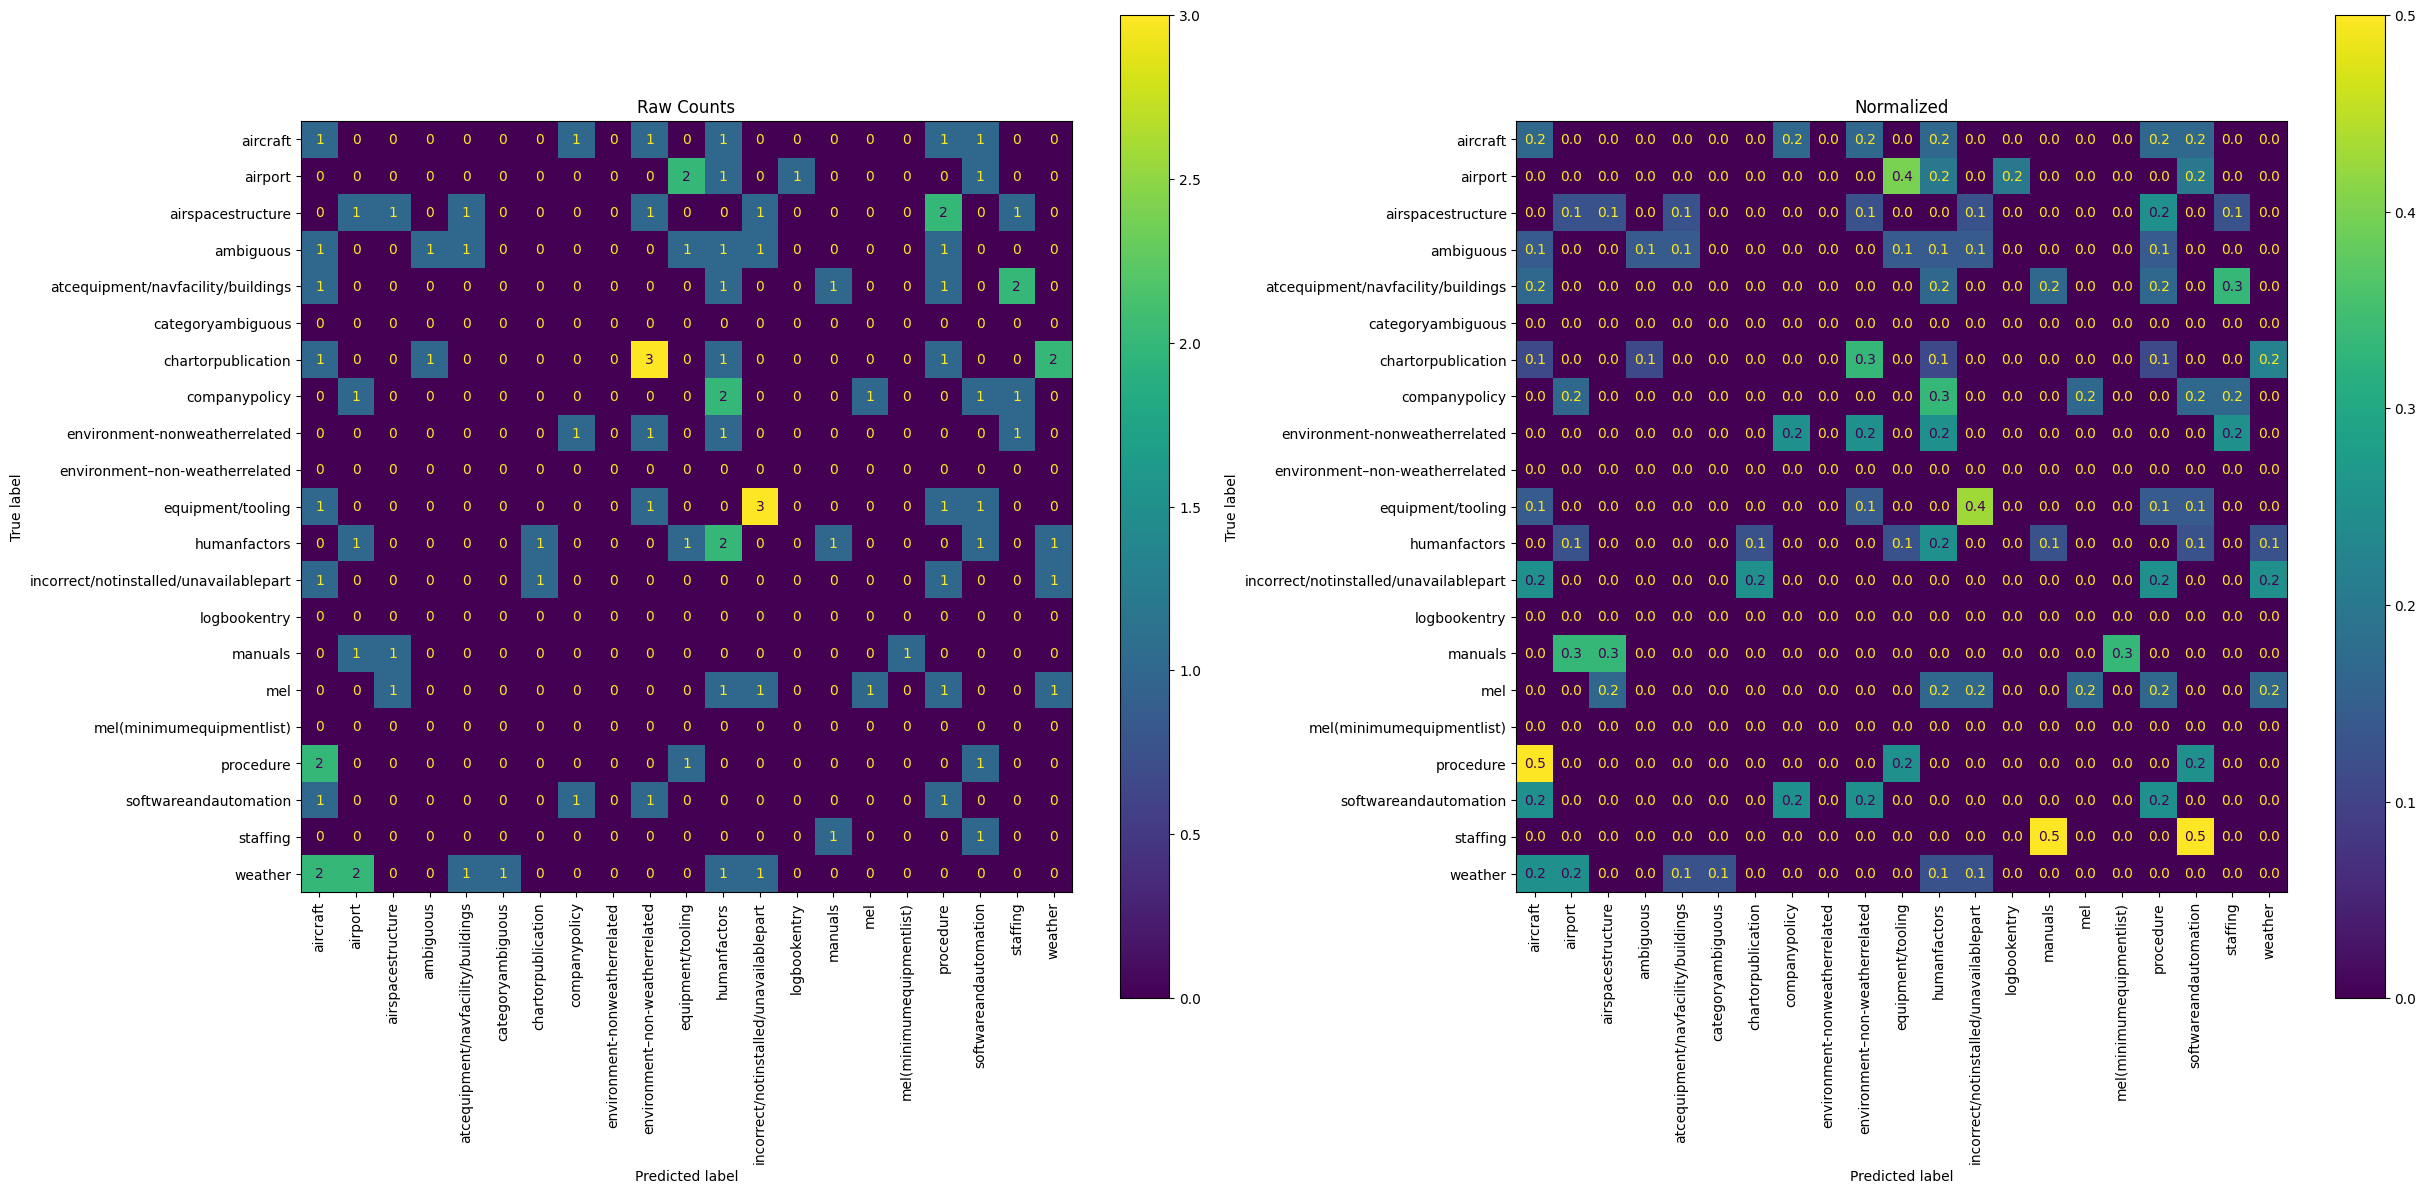

In [230]:
# GLM-4.7 Context Engineering
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Metrics
print(classification_report(df['y_true'], df['pred']))

# Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 12))

ConfusionMatrixDisplay.from_predictions(
    df['y_true'],
    df['pred'],
    xticks_rotation='vertical',
    ax=ax1
)
ax1.set_title("Raw Counts")

ConfusionMatrixDisplay.from_predictions(
    df['y_true'],
    df['pred'],
    xticks_rotation='vertical',
    normalize='true',
    values_format='.1f',
    ax=ax2
)
ax2.set_title("Normalized")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

                                        precision    recall  f1-score   support

                              aircraft       0.45      0.90      0.60        10
                               airport       0.40      0.40      0.40        10
                     airspacestructure       0.56      0.50      0.53        10
                             ambiguous       0.00      0.00      0.00        10
    atcequipment/navfacility/buildings       0.64      0.70      0.67        10
                    chartorpublication       0.83      0.50      0.62        10
                         companypolicy       0.40      0.20      0.27        10
          environmentnonweatherrelated       0.43      0.30      0.35        10
                    environmentweather       0.00      0.00      0.00         0
                     equipment/tooling       0.50      0.30      0.38        10
                          humanfactors       0.16      0.50      0.24        10
incorrect/notinstalled/unavailablepart 

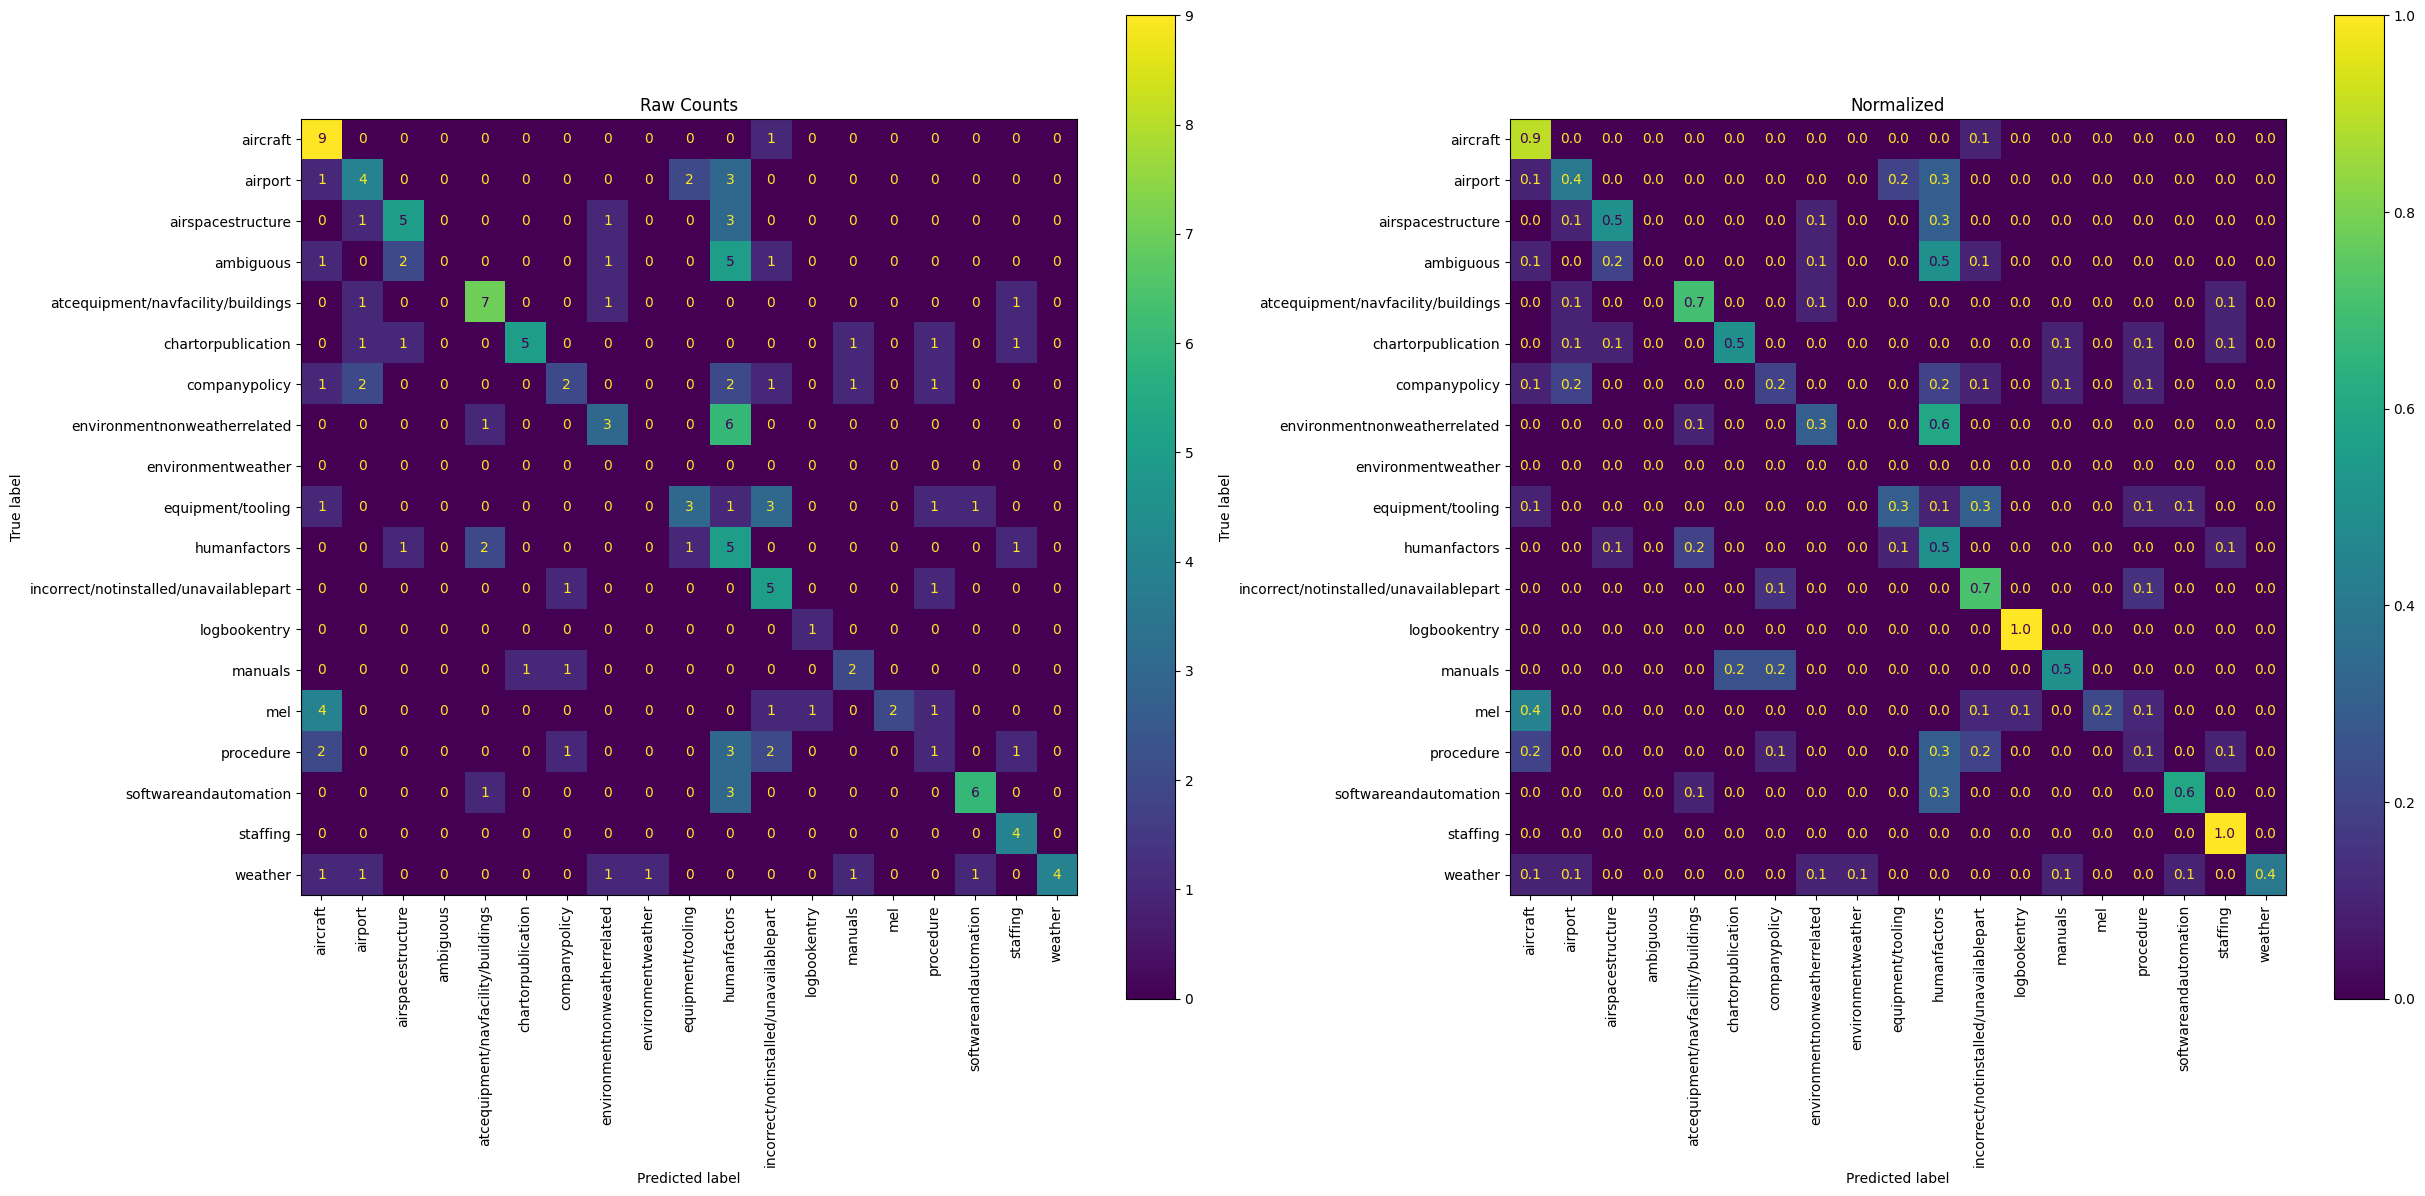

In [266]:
# "ByteDance/Seed-2.0-mini" Context Engineering

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Metrics
print(classification_report(df['y_true'], df['pred']))

# Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 12))

ConfusionMatrixDisplay.from_predictions(
    df['y_true'],
    df['pred'],
    xticks_rotation='vertical',
    ax=ax1
)
ax1.set_title("Raw Counts")

ConfusionMatrixDisplay.from_predictions(
    df['y_true'],
    df['pred'],
    xticks_rotation='vertical',
    normalize='true',
    values_format='.1f',
    ax=ax2
)
ax2.set_title("Normalized")

plt.tight_layout()
plt.show()